In [1]:
import os

from charset_normalizer.cli import query_yes_no

os.environ["SCIPY_ARRAY_API"] = "1"

import pandas as pd
import numpy as np
import seaborn as sns

from dpks import QuantMatrix



In [2]:
clinical_columns = [
    "sao2_ambulance",
    "resp_frequency_ambulance",
    "heart_rate_ambulance",
    "syst_bp_ambulance",
    "map_ambulance",
    "mental_status_ambulance", # categorical
    "temperature_ambulance",
    "crea_emergency_department",
    "bili_emergency_department",
    "crp_day1",
    "trc_emergency_department",
    "sex",
    "age"
]

continuous_clinical_columns = [
    "sao2_ambulance",
    "resp_frequency_ambulance",
    "heart_rate_ambulance",
    "syst_bp_ambulance",
    "map_ambulance",
    "temperature_ambulance",
    "crea_emergency_department",
    "bili_emergency_department",
    "trc_emergency_department",
    "crp_day1",
    "age"
]

categorical_clinical_columns = [
    "mental_status_ambulance",
]

selected_features = [
    'VWF_HUMAN',
    'CRP_HUMAN',
    'AACT_HUMAN',
    'B2MG_HUMAN',
    'IBP3_HUMAN',
    'FIBG_HUMAN',
    'CYTC_HUMAN',
    'VCAM1_HUMAN',
    'LBP_HUMAN',
    'A2GL_HUMAN'
]

In [3]:
continuous_clinical_columns.extend(selected_features)

In [4]:

def preprocess_design_matrix(design_matrix):

    # design_matrix = design_matrix[
    #     ((design_matrix['Sepsis Diagnosis Probability'] >= 0.8) | 
    #     (design_matrix['Sepsis Diagnosis Probability'] <= 0.50))
    # ].copy()

    design_matrix['group'] = 1

    design_matrix['sample'] = design_matrix['injection']

    return design_matrix

In [5]:
def preprocess_data(raw_data, design_matrix):

    quant_matrix = QuantMatrix(
        quantification_file=raw_data[['Protein'] + [sample for sample in design_matrix['sample'].values]].copy(),
        design_matrix_file=design_matrix,
        annotation_fasta_file="../0_data/2023-04-24-UP000005640.fas"
    )

    quant_data = quant_matrix.to_df()
    
    quant_data = quant_data[~((quant_data["ProteinLabel"].str.startswith("HV")) | (quant_data["ProteinLabel"].str.startswith("LV")) | quant_data["ProteinLabel"].str.startswith("KV"))]
    quant_data = quant_data[~quant_data["ProteinLabel"].str.startswith("IG")]
    quant_data = quant_data[~((quant_data["ProteinLabel"] == "HBA_HUMAN") | (quant_data["ProteinLabel"] == "HBB_HUMAN") | (quant_data["ProteinLabel"] == "HBD_HUMAN") | (quant_data["ProteinLabel"] == "HEMO_HUMAN"))]

    quant_matrix = QuantMatrix(
        quantification_file=quant_data,
        design_matrix_file=design_matrix,
        annotation_fasta_file="../0_data/2023-04-24-UP000005640.fas"
    )

    return quant_matrix.annotate()     


In [6]:
ms_data = pd.read_csv(
    "../0_data/proteins_test_filtered.tsv"
    , sep="\t"
)

In [7]:
design_matrix = pd.read_csv(
    "../0_data/design_matrix_test.tsv",
    sep='\t'
)

In [8]:
ms_data_test = pd.read_csv(
    "../0_data/proteins_val_filtered.tsv"
    , sep="\t"
)
design_matrix_test = pd.read_csv(
    "../0_data/design_matrix_validation.tsv",
    sep='\t'
)

In [9]:
design_matrix['survival_30_day'] = np.where(design_matrix['survival_days'] <= 30, 1, 0)
design_matrix_test['survival_30_day'] = np.where(design_matrix_test['survival_days'] <= 30, 1, 0)


design_matrix['future_deterioration'] = np.where(
    design_matrix['sofa_score_increase_day2'] > 1, 1, np.where(
        design_matrix['sofa_score_increase_day3'] > 1, 1, 0
    )
)

design_matrix_test['future_deterioration'] = np.where(
    design_matrix_test['sofa_score_increase_day2'] > 1, 1, np.where(
        design_matrix_test['sofa_score_increase_day3'] > 1, 1, 0
    )
)

In [10]:
design_matrix_train = preprocess_design_matrix(design_matrix)

quant_matrix_train = preprocess_data(ms_data, design_matrix=design_matrix_train)

In [11]:
quant_matrix_train_df = quant_matrix_train.to_df()
quant_matrix_train_df = quant_matrix_train_df[quant_matrix_train_df['ProteinLabel'].isin(selected_features)]

In [12]:
qm_filtered_train = (

    QuantMatrix(
        quantification_file=quant_matrix_train_df,
        design_matrix_file=design_matrix_train
    )

)

In [13]:
training_data, y = qm_filtered_train.to_ml(feature_column="ProteinLabel")

In [14]:
training_data = training_data.join(
    design_matrix_train.set_index("injection")
)

In [15]:
from sklearn.preprocessing import StandardScaler, LabelBinarizer
from sklearn.impute import SimpleImputer


In [16]:
design_matrix_test = preprocess_design_matrix(design_matrix_test)

quant_matrix_test = preprocess_data(ms_data_test, design_matrix=design_matrix_test)

In [17]:
quant_matrix_test_df = quant_matrix_test.to_df()
quant_matrix_test_df = quant_matrix_test_df[quant_matrix_test_df['ProteinLabel'].isin(selected_features)]

In [18]:
qm_filtered_test = (
    
    QuantMatrix(
        quantification_file=quant_matrix_test_df,
        design_matrix_file=design_matrix_test
    )
    
)

In [19]:
testing_data, y_test = qm_filtered_test.to_ml(feature_column="ProteinLabel")

In [20]:
testing_data = testing_data.join(
    design_matrix_test.set_index("injection")
)

In [21]:
from sklearn.preprocessing import StandardScaler, LabelBinarizer, MinMaxScaler
from sklearn.impute import SimpleImputer

clinical_scaler = StandardScaler()
protein_scaler = StandardScaler()

clinical_imputer = SimpleImputer()
sex_scaler = MinMaxScaler((0, 1))
constant_imputer = SimpleImputer(strategy="constant", fill_value=1.0)

training_data[continuous_clinical_columns] = clinical_imputer.fit_transform(training_data[continuous_clinical_columns])
training_data[["mental_status_ambulance"]] = constant_imputer.fit_transform(training_data[["mental_status_ambulance"]])

training_data[continuous_clinical_columns] = clinical_scaler.fit_transform(training_data[continuous_clinical_columns])
training_data[['sex']] = sex_scaler.fit_transform(training_data[['sex']])

testing_data[continuous_clinical_columns] = clinical_imputer.transform(testing_data[continuous_clinical_columns])
testing_data[["mental_status_ambulance"]] = constant_imputer.transform(testing_data[["mental_status_ambulance"]])

testing_data[continuous_clinical_columns] = clinical_scaler.transform(testing_data[continuous_clinical_columns])
testing_data[['sex']] = sex_scaler.transform(testing_data[['sex']])


In [22]:
training_data[selected_features]

,VWF_HUMAN,CRP_HUMAN,AACT_HUMAN,B2MG_HUMAN,IBP3_HUMAN,FIBG_HUMAN,CYTC_HUMAN,VCAM1_HUMAN,LBP_HUMAN,A2GL_HUMAN
SA_BOX_9-159_S1-D9_1_6172,-0.861609,-0.832145,-1.522666,-0.396967,0.871086,-0.824617,-0.984431,-0.750702,-0.942249,-2.180324
SA_BOX_7-267_S4-H8_1_5971,3.443652,1.164734,1.136805,1.308009,1.218496,1.277020,1.364034,0.670960,1.475495,0.518575
SA_BOX_15-464_S4-G9_1_6763,-0.804806,0.899652,0.517773,-1.113088,0.116857,1.108040,-1.312836,-1.421451,0.904487,1.349402
SA_BOX_2-1700_S2-D11_1_6971,-0.417686,0.697986,0.292720,-0.008170,-1.498996,0.540939,0.215088,-0.264485,-0.060581,0.903033
SA_BOX_7-1728_S4-F9_1_5977,-0.460148,-0.558110,-0.058111,0.514374,0.440166,0.288371,0.994396,0.179048,0.526041,-0.700227
...,...,...,...,...,...,...,...,...,...,...
SA_BOX_6-659_S2-F10_1_5887,-0.081071,0.122692,-0.299779,1.346329,1.365108,-0.412568,1.595662,0.767814,0.294558,0.465016
SA_BOX_7-2061_S4-H5_1_5946,-0.449211,0.018225,-0.512041,-0.442658,0.946659,-0.233424,-1.845724,-0.640151,0.819934,0.773169
SA_BOX_2-764_S2-G2_1_6901,0.037911,0.712995,0.542622,0.849833,0.372905,1.110575,1.146930,0.547027,-0.000880,0.746386
SA_BOX_6-774_S2-D10_1_5885,0.623011,1.253079,0.701872,-0.104324,0.461945,0.300801,-0.278259,1.354294,2.188609,2.305890


In [23]:
training_data = training_data.reset_index(drop=True)

In [24]:
testing_data = testing_data.reset_index(drop=True)

In [25]:
from dfmodel import DigitalFamilyBinary

df_estimator = DigitalFamilyBinary(
    n_neighbors=10,
    neighbor_metric="euclidean",
    bootstrap_iterations=1000,
)

df_estimator.fit(training_data, features=selected_features)

In [26]:
training_data['Sepsis Rates'] = df_estimator.predict(training_data, features=selected_features, target_column="sepsis_or_septic_shock", bootstrap=False)
training_data['Infection Rates'] = df_estimator.predict(training_data, features=selected_features, target_column="verified_infection", bootstrap=False)
training_data['Future Organ Dysfunction'] = df_estimator.predict(training_data, features=selected_features, target_column="future_deterioration", bootstrap=False)
training_data['30 Day Mortality'] = df_estimator.predict(training_data, features=selected_features, target_column="survival_30_day", bootstrap=False)

In [28]:
from fa2_modified import ForceAtlas2
import matplotlib.pyplot as plt
import networkx as nx

G = df_estimator.network_

positions = nx.forceatlas2_layout(
    G,
    max_iter=1000,
    seed=0,
    #strong_gravity=True,
    dissuade_hubs=True
)

In [29]:
display_columns = [
    "Sepsis Rates",
    "Infection Rates",
    "Future Organ Dysfunction",
    "30 Day Mortality",
]

In [30]:

def networkx_to_igraph(nx_graph):
    ig_graph = ig.Graph(directed=nx_graph.is_directed())
    ig_graph.add_vertices(list(nx_graph.nodes()))
    ig_graph.add_edges(list(nx_graph.edges()))

    # Optional: transfer node and edge attributes
    for node, attrs in nx_graph.nodes(data=True):
        for attr, value in attrs.items():
            ig_graph.vs[node][attr] = value

    for i, (u, v, attrs) in enumerate(nx_graph.edges(data=True)):
        for attr, value in attrs.items():
            ig_graph.es[i][attr] = value

    return ig_graph


In [31]:
import igraph as ig
import leidenalg as la

h = networkx_to_igraph(G)

/Users/aaron/Documents/projects/sadt/notebooks/revisions/second_250806/DigitalFamilyAnalysis/.venv/lib/python3.12/site-packages/leidenalg/VertexPartition.py:388: SyntaxWarning: invalid escape sequence '\m'
  """ Implements modularity. This quality function is well-defined only for positive edge weights.
/Users/aaron/Documents/projects/sadt/notebooks/revisions/second_250806/DigitalFamilyAnalysis/.venv/lib/python3.12/site-packages/leidenalg/VertexPartition.py:761: SyntaxWarning: invalid escape sequence '\m'
  """ Implements Reichardt and Bornholdt's Potts model with a configuration null model.
/Users/aaron/Documents/projects/sadt/notebooks/revisions/second_250806/DigitalFamilyAnalysis/.venv/lib/python3.12/site-packages/leidenalg/Optimiser.py:7: SyntaxWarning: invalid escape sequence '\g'
  """ Class for doing community detection using the Leiden algorithm.
/Users/aaron/Documents/projects/sadt/notebooks/revisions/second_250806/DigitalFamilyAnalysis/.venv/lib/python3.12/site-packages/leide

In [39]:
partition = la.find_partition(
    h,
    la.RBConfigurationVertexPartition,
    resolution_parameter = 0.5
)

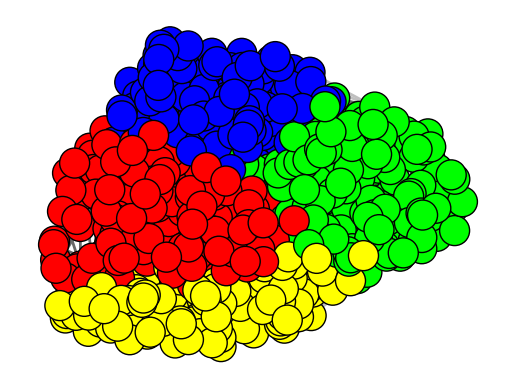

In [40]:

fig, ax = plt.subplots()

ig.plot(partition, target=ax)

In [41]:
training_data['Community'] = [partition.membership[v.index] for v in h.vs]

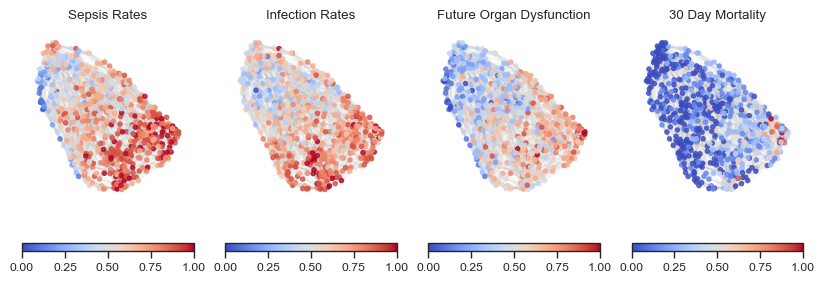

In [42]:
import matplotlib.pyplot as plt
sns.set_theme(font="Arial", style="white", context="paper")


fig, axs = plt.subplots(
    nrows=1,
    ncols=4
)

for i, col in enumerate(display_columns):

    # values = training_data[col].to_numpy()
    # cmap = plt.cm.coolwarm
    # norm = plt.Normalize(vmin=training_data[col].min(), vmax=training_data[col].max())
    # colors = cmap(norm(values))

    color_normalizer = MinMaxScaler((0, 1))

    values = MinMaxScaler().fit_transform(training_data[[col]])

    color_map = dict(zip(training_data.index, values))
    node_colors = [color_map[node] for node in G.nodes()]

    nx.draw_networkx_nodes(G, positions, node_size=10, node_color=node_colors, cmap="coolwarm", alpha=0.8, ax=axs[i])
    nx.draw_networkx_edges(G, positions, edge_color="gray", alpha=0.05, ax=axs[i])

    axs[i].axis("off")

    axs[i].set_title(col)

    sm = plt.cm.ScalarMappable(cmap="coolwarm")
    cbar = fig.colorbar(sm, ax=axs[i], orientation="horizontal")

    #cbar = fig.colorbar(ax=axs[i])

fig.set_size_inches((8.27, 3))
plt.tight_layout()

(np.float64(-836.5110076904297),
 np.float64(984.0015472412109),
 np.float64(-632.7523773193359),
 np.float64(647.5377166748046))

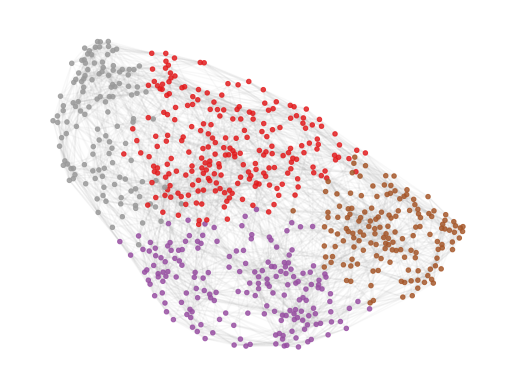

In [43]:
import matplotlib.pyplot as plt
sns.set_theme(font="Arial", style="white", context="paper")

fig, ax = plt.subplots()

values = training_data['Community'].to_list()

cmap = sns.color_palette("Set1", training_data['Community'].unique().shape[0])
color_map = dict(zip(training_data.index, values))
node_colors = [color_map[node] for node in G.nodes()]

nx.draw_networkx_nodes(G, positions, node_size=10, node_color=node_colors, cmap="Set1", alpha=0.8, ax=ax)
nx.draw_networkx_edges(G, positions, edge_color="gray", alpha=0.05, ax=ax)

ax.axis("off")

# sm = plt.cm.ScalarMappable(cmap="coolwarm")
# cbar = fig.colorbar(sm, ax=axs[i], orientation="horizontal")

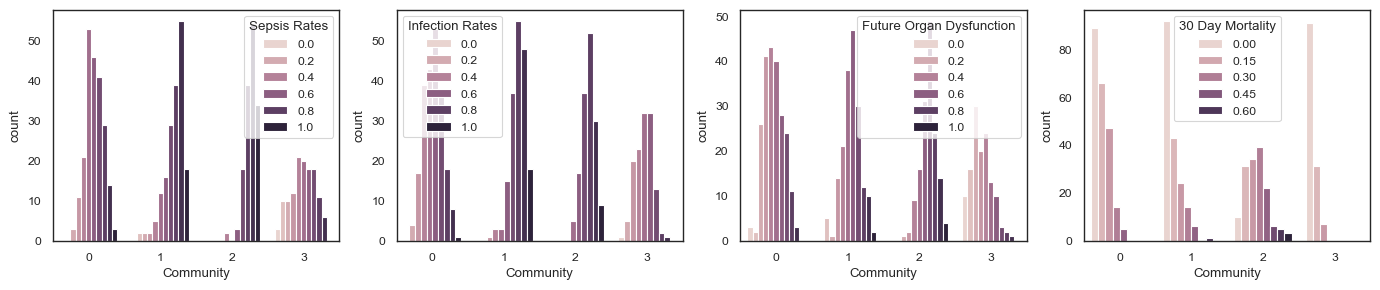

In [44]:

fig, axs = plt.subplots(
    nrows=1,
    ncols=4
)

for i, col in enumerate(display_columns):

    sns.countplot(
        data=training_data,
        x="Community",
        hue=col,
        ax=axs[i]
    )

fig.set_size_inches((17, 3))

In [45]:
training_data['Safe Zone'] = np.where(training_data['Community'] == 3, 1, 0)

(np.float64(-836.5110076904297),
 np.float64(984.0015472412109),
 np.float64(-632.7523773193359),
 np.float64(647.5377166748046))

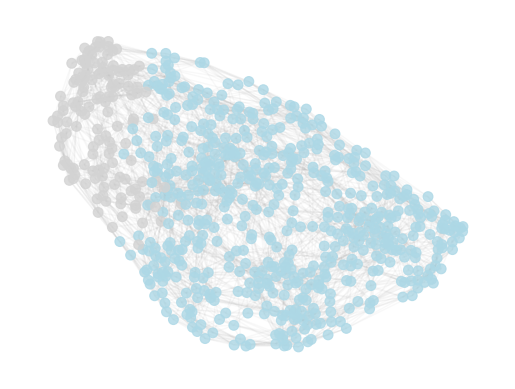

In [46]:
import matplotlib.pyplot as plt
sns.set_theme(font="Arial", style="white", context="paper")

fig, ax = plt.subplots()

values = np.where(training_data['Community'] == 3, 1, 0)

cmap = sns.color_palette(["#ADD8E6", "#D3D3D3"])
color_map = dict(zip(training_data.index, values))

node_colors = [cmap[color_map[i]] for i in G.nodes()]

nx.draw_networkx_nodes(G, positions, node_size=50, node_color=node_colors, alpha=0.8, ax=ax)
nx.draw_networkx_edges(G, positions, edge_color="gray", alpha=0.05, ax=ax)

ax.axis("off")

In [47]:
testing_data['Sepsis Rates'] = df_estimator.predict(testing_data, features=selected_features, target_column="sepsis_or_septic_shock", bootstrap=False)
testing_data['Infection Rates'] = df_estimator.predict(testing_data, features=selected_features, target_column="verified_infection", bootstrap=False)
testing_data['Future Organ Dysfunction'] = df_estimator.predict(testing_data, features=selected_features, target_column="future_deterioration", bootstrap=False)
testing_data['30 Day Mortality'] = df_estimator.predict(testing_data, features=selected_features, target_column="survival_30_day", bootstrap=False)

<Axes: xlabel='Future Organ Dysfunction', ylabel='count'>

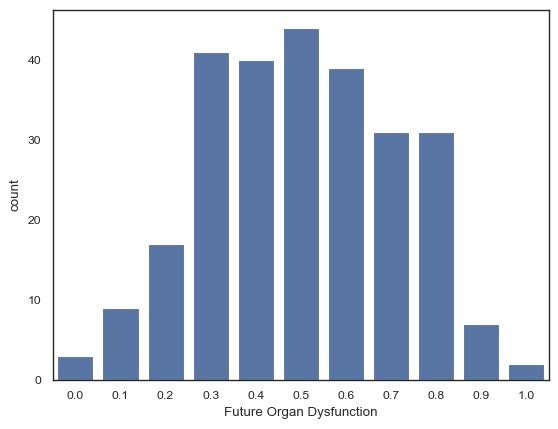

In [278]:
sns.countplot(
    data=testing_data,
    x="Future Organ Dysfunction",
)

<Axes: xlabel='30 Day Mortality', ylabel='count'>

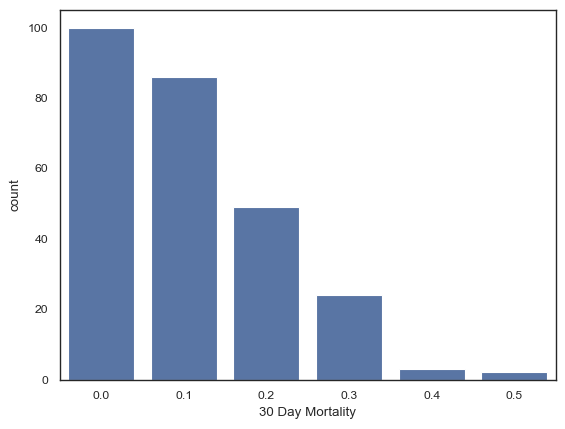

In [279]:
sns.countplot(
    data=testing_data,
    x="30 Day Mortality",
)

In [304]:
[(sample_graph.nodes[17]['Future Organ Dysfunction'] < 0.3 and sample_graph.nodes[17]['30 Day Mortality'] < 0.1) for n in sample_graph.neighbors(17)]

[False,
 False,
 False,
 False,
 False,
 False,
 False,
 False,
 False,
 False,
 False,
 False,
 False,
 False]

In [311]:
all((True and False) for n in sample_graph.neighbors(17))

False

In [306]:
[sample_graph.nodes[17]['30 Day Mortality'] < 0.1 for n in sample_graph.neighbors(17)]

[False,
 False,
 False,
 False,
 False,
 False,
 False,
 False,
 False,
 False,
 False,
 False,
 False,
 False]

In [414]:
def goal(graph, node):

    return all(
        graph.nodes[n]['Future Organ Dysfunction'] < 0.5 for n in graph.neighbors(node)
    )
    # return all(
    #     graph.nodes[n]['Safe Zone'] == 1.0 for n in graph.neighbors(node)
    # )

def heuristic(graph, u, v):

    u_data = np.array([graph.nodes[u][col] for col in selected_features])
    v_data = np.array([graph.nodes[v][col] for col in selected_features])

    return np.linalg.norm(u_data - v_data) # returns Euclidean distance between target and source


def find_path(graph, source):

    visited = set()

    queue = [(0, source, [source])]

    while queue:

        queue.sort()

        cost, current, path = queue.pop(0)

        if goal(graph, current):

            return path

        visited.add(current)
        for n in graph.neighbors(current):
            if n not in visited:
                h = heuristic(graph, n, source)
                queue.append((cost + h, n, path + [n]))

    return []



In [415]:
shortest_paths = dict()


for idx, row in testing_data.iterrows():

    if row['Future Organ Dysfunction'] >= 0.5:

        sample_graph = df_estimator.model_sample(
            row,
            features=selected_features,
        )

        query_id = len(sample_graph) - 1

        distances, neighbors = df_estimator.neighbors(
            pd.DataFrame([row]),
            features=selected_features,
        )

        neighbors = neighbors[0, :]
        distances = distances[0, :]

        neighborhood_positions = []

        for neighbor in neighbors:

            pos = positions[neighbor]

            neighborhood_positions.append(pos)

        neighborhood_positions = np.array(neighborhood_positions)

        centroid_position = neighborhood_positions.mean(axis=0)

        new_positions = positions.copy()

        new_positions[len(new_positions)] = centroid_position

        training_data['source'] = "base"
        training_data['size'] = 20
        row['source'] = "query"
        row['size'] = 100

        combined = pd.concat(
            [training_data, pd.DataFrame([row])],
            ignore_index=True
        )

        nx.set_node_attributes(sample_graph, combined.to_dict(orient="index"))

        shortest_path = find_path(sample_graph, query_id)

        shortest_paths[idx] = shortest_path

        categories = combined['source'].unique()
        palette = sns.color_palette('Set2', n_colors=len(categories))
        category_color_map = dict(zip(categories, palette))

        sample_name = row['sample']

        fig, ax = plt.subplots()

        node_colors = [category_color_map[sample_graph.nodes[node]['source']] for node in sample_graph.nodes]


        highlight_nodes = set(shortest_path)

        node_colors = ["yellow" if node in highlight_nodes else node_colors[node] for node in sample_graph.nodes()]

        nx.draw_networkx_nodes(sample_graph, new_positions, node_size=combined['size'].to_list(), node_color=node_colors, alpha=0.8, ax=ax)

        nx.draw_networkx_nodes(sample_graph, new_positions,
                               nodelist=[680],
                               node_size=200,
                               node_color='orange',
                               node_shape='x',
                               ax=ax)

        nx.draw_networkx_edges(sample_graph, new_positions, edge_color="gray", alpha=0.05)
        ax.axis('off')
        fig.savefig(f"trajectories/{sample_name}.pdf", dpi=300, bbox_inches="tight")
        plt.close()



KeyboardInterrupt: 

In [416]:
shortest_path

[680, 354, 552, 456]

In [417]:
for idx, path in shortest_paths.items():

    source = testing_data.loc[idx]

    path_ = path#[1:]

    if len(path_) > 3:

        #if source['30 Day Mortality'] > 0.4:

        break

In [418]:
path_

[680, 76, 167, 471, 456]

In [419]:
source

VWF_HUMAN                                    0.094301
A2GL_HUMAN                                   0.553883
FIBG_HUMAN                                   0.488438
CRP_HUMAN                                    0.743588
IBP3_HUMAN                                  -0.011683
                                      ...            
sample                      SA_BOX1_1560_S1-G1_1_4421
Sepsis Rates                                      1.0
Infection Rates                                   0.7
Future Organ Dysfunction                          0.8
30 Day Mortality                                  0.2
Name: 0, Length: 82, dtype: object

In [420]:
test_row = pd.DataFrame(testing_data.loc[idx])
test_row

,0
VWF_HUMAN,0.094301
A2GL_HUMAN,0.553883
FIBG_HUMAN,0.488438
CRP_HUMAN,0.743588
IBP3_HUMAN,-0.011683
...,...
sample,SA_BOX1_1560_S1-G1_1_4421
Sepsis Rates,1.0
Infection Rates,0.7
Future Organ Dysfunction,0.8


In [421]:
pd.concat(
    [training_data, test_row.T],
    ignore_index=True
).tail()

,VWF_HUMAN,A2GL_HUMAN,FIBG_HUMAN,CRP_HUMAN,IBP3_HUMAN,LBP_HUMAN,B2MG_HUMAN,VCAM1_HUMAN,AACT_HUMAN,CYTC_HUMAN,...,group,sample,Sepsis Rates,Infection Rates,Future Organ Dysfunction,30 Day Mortality,Community,Safe Zone,source,size
676,-0.449211,0.773169,-0.233424,0.018225,0.946659,0.819934,-0.442658,-0.640151,-0.512041,-1.845724,...,1,SA_BOX_7-2061_S4-H5_1_5946,0.6,0.8,0.4,0.0,1.0,0.0,base,20.0
677,0.037911,0.746386,1.110575,0.712995,0.372905,-0.00088,0.849833,0.547027,0.542622,1.14693,...,1,SA_BOX_2-764_S2-G2_1_6901,0.6,0.6,0.7,0.3,2.0,0.0,base,20.0
678,0.623011,2.30589,0.300801,1.253079,0.461945,2.188609,-0.104324,1.354294,0.701872,-0.278259,...,1,SA_BOX_6-774_S2-D10_1_5885,0.8,0.9,0.5,0.0,1.0,0.0,base,20.0
679,-0.395037,-1.18518,0.087523,-0.707024,-0.240829,0.294424,-0.272349,0.035558,0.403982,-0.276329,...,1,SA_BOX_4-1196_S5-A2_1_5621,0.6,0.7,0.4,0.0,0.0,0.0,base,20.0
680,0.094301,0.553883,0.488438,0.743588,-0.011683,0.533738,0.339763,1.127484,-0.01257,0.749306,...,1,SA_BOX1_1560_S1-G1_1_4421,1.0,0.7,0.8,0.2,NaN,NaN,NaN,NaN


In [422]:
combined = pd.concat(
    [training_data, test_row.T],
    ignore_index=True
)
combined.tail()

,VWF_HUMAN,A2GL_HUMAN,FIBG_HUMAN,CRP_HUMAN,IBP3_HUMAN,LBP_HUMAN,B2MG_HUMAN,VCAM1_HUMAN,AACT_HUMAN,CYTC_HUMAN,...,group,sample,Sepsis Rates,Infection Rates,Future Organ Dysfunction,30 Day Mortality,Community,Safe Zone,source,size
676,-0.449211,0.773169,-0.233424,0.018225,0.946659,0.819934,-0.442658,-0.640151,-0.512041,-1.845724,...,1,SA_BOX_7-2061_S4-H5_1_5946,0.6,0.8,0.4,0.0,1.0,0.0,base,20.0
677,0.037911,0.746386,1.110575,0.712995,0.372905,-0.00088,0.849833,0.547027,0.542622,1.14693,...,1,SA_BOX_2-764_S2-G2_1_6901,0.6,0.6,0.7,0.3,2.0,0.0,base,20.0
678,0.623011,2.30589,0.300801,1.253079,0.461945,2.188609,-0.104324,1.354294,0.701872,-0.278259,...,1,SA_BOX_6-774_S2-D10_1_5885,0.8,0.9,0.5,0.0,1.0,0.0,base,20.0
679,-0.395037,-1.18518,0.087523,-0.707024,-0.240829,0.294424,-0.272349,0.035558,0.403982,-0.276329,...,1,SA_BOX_4-1196_S5-A2_1_5621,0.6,0.7,0.4,0.0,0.0,0.0,base,20.0
680,0.094301,0.553883,0.488438,0.743588,-0.011683,0.533738,0.339763,1.127484,-0.01257,0.749306,...,1,SA_BOX1_1560_S1-G1_1_4421,1.0,0.7,0.8,0.2,NaN,NaN,NaN,NaN


In [423]:
test = combined.loc[path_, :]#[selected_features]

In [424]:
distances, knn_idxs = df_estimator.neighbors(test, features=selected_features)

In [425]:
transformed_values = []

for idx in range(knn_idxs.shape[0]):

    neighbors = knn_idxs[idx, :]

    transformed_values.append(combined.loc[neighbors][selected_features].mean().T)

In [426]:
test = pd.concat(transformed_values, axis=1).T

In [427]:
test['Steps'] = list(range(len(test)))

In [428]:
test

,VWF_HUMAN,CRP_HUMAN,AACT_HUMAN,B2MG_HUMAN,IBP3_HUMAN,FIBG_HUMAN,CYTC_HUMAN,VCAM1_HUMAN,LBP_HUMAN,A2GL_HUMAN,Steps
0,0.331273,0.801892,0.475065,0.428112,0.466376,0.557777,0.787001,0.656286,0.664359,0.577309,0
1,0.530104,0.700301,0.54269,0.276667,0.541443,0.605077,0.549428,0.802521,0.736528,0.288169,1
2,0.191824,0.040466,-0.016527,-0.031895,0.539962,0.177165,0.077636,0.058527,0.109296,-0.252501,2
3,0.127555,-0.219607,-0.015694,0.23278,0.360852,0.078306,0.553326,-0.101228,-0.128758,-0.552629,3
4,0.37128,-0.583052,-0.582456,-0.164165,0.42157,-0.354997,0.141037,0.178611,-0.158577,-0.852575,4


In [429]:
melted = test.melt(id_vars="Steps")
melted

,Steps,variable,value
0,0,VWF_HUMAN,0.331273
1,1,VWF_HUMAN,0.530104
2,2,VWF_HUMAN,0.191824
3,3,VWF_HUMAN,0.127555
4,4,VWF_HUMAN,0.37128
5,0,CRP_HUMAN,0.801892
6,1,CRP_HUMAN,0.700301
7,2,CRP_HUMAN,0.040466
8,3,CRP_HUMAN,-0.219607
9,4,CRP_HUMAN,-0.583052


In [430]:
test

,VWF_HUMAN,CRP_HUMAN,AACT_HUMAN,B2MG_HUMAN,IBP3_HUMAN,FIBG_HUMAN,CYTC_HUMAN,VCAM1_HUMAN,LBP_HUMAN,A2GL_HUMAN,Steps
0,0.331273,0.801892,0.475065,0.428112,0.466376,0.557777,0.787001,0.656286,0.664359,0.577309,0
1,0.530104,0.700301,0.54269,0.276667,0.541443,0.605077,0.549428,0.802521,0.736528,0.288169,1
2,0.191824,0.040466,-0.016527,-0.031895,0.539962,0.177165,0.077636,0.058527,0.109296,-0.252501,2
3,0.127555,-0.219607,-0.015694,0.23278,0.360852,0.078306,0.553326,-0.101228,-0.128758,-0.552629,3
4,0.37128,-0.583052,-0.582456,-0.164165,0.42157,-0.354997,0.141037,0.178611,-0.158577,-0.852575,4


In [431]:
test2 = test.set_index("Steps").T
test2

Steps,0,1,2,3,4
VWF_HUMAN,0.331273,0.530104,0.191824,0.127555,0.37128
CRP_HUMAN,0.801892,0.700301,0.040466,-0.219607,-0.583052
AACT_HUMAN,0.475065,0.54269,-0.016527,-0.015694,-0.582456
B2MG_HUMAN,0.428112,0.276667,-0.031895,0.23278,-0.164165
IBP3_HUMAN,0.466376,0.541443,0.539962,0.360852,0.42157
FIBG_HUMAN,0.557777,0.605077,0.177165,0.078306,-0.354997
CYTC_HUMAN,0.787001,0.549428,0.077636,0.553326,0.141037
VCAM1_HUMAN,0.656286,0.802521,0.058527,-0.101228,0.178611
LBP_HUMAN,0.664359,0.736528,0.109296,-0.128758,-0.158577
A2GL_HUMAN,0.577309,0.288169,-0.252501,-0.552629,-0.852575


<Axes: xlabel='Steps'>

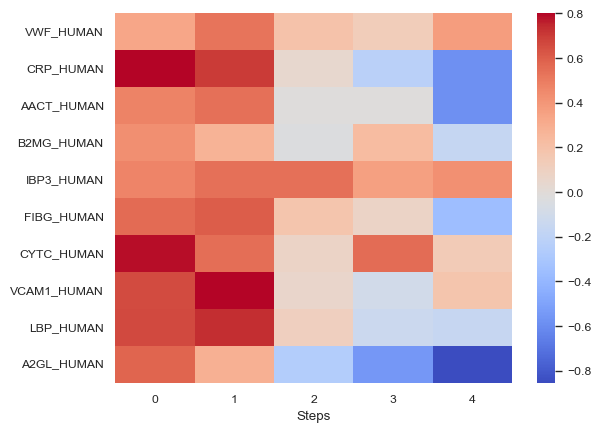

In [440]:
sns.heatmap(
    data=test2.astype(float),
    cmap="coolwarm"
)

<Axes: xlabel='Steps', ylabel='value'>

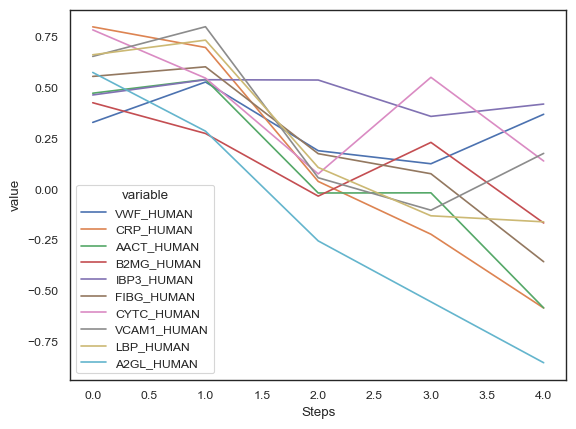

In [441]:
sns.lineplot(
    data=melted,
    x="Steps",
    y="value",
    hue="variable",
)

In [413]:
source['sample']

'SA_BOX1_1560_S1-G1_1_4421'

In [66]:
sample_graph.nodes[query_id]

{'VWF_HUMAN': -1.2214062925540012,
 'A2GL_HUMAN': -0.14885941554186513,
 'FIBG_HUMAN': -0.5684867500027448,
 'CRP_HUMAN': 0.01786569392093691,
 'IBP3_HUMAN': 0.01215076682858547,
 'LBP_HUMAN': -0.2745108174221751,
 'B2MG_HUMAN': 0.18141517779005786,
 'VCAM1_HUMAN': 0.4393865252388264,
 'AACT_HUMAN': 0.3961656665890426,
 'CYTC_HUMAN': 0.4054657963896336,
 'Unnamed: 0': 7,
 'sao2_ambulance': -1.7464077040777253,
 'resp_frequency_ambulance': 1.1468762575392177,
 'heart_rate_ambulance': 0.5040993489460571,
 'syst_bp_ambulance': -0.5388054775017368,
 'map_ambulance': 0.0,
 'mental_status_ambulance': 1.0,
 'temperature_ambulance': -1.6692959561260463,
 'crea_emergency_department': 0.1459419685386229,
 'bili_emergency_department': 0.0,
 'crp_day1': -0.5492602738005321,
 'trc_emergency_department': 0.11457925775739843,
 'sex': 0.0,
 'age': 0.6861832811263218,
 'diagnosis_sepsis_student_3': 4.0,
 'sepsis_or_septic_shock': 1.0,
 'survival_days': nan,
 'sofa_score_increase_day1': 4.0,
 'sofa_scor

In [ ]:
from sklearn.metrics import mean_squared_error, accuracy_score
from sklearn.neighbors import NearestNeighbors
import matplotlib.pyplot as plt


X_test_results = pd.concat([X_test.reset_index(),  df_estimator.bootstrap_results_df], axis=1)

fig, ax = plt.subplots()

protein_estimated_sepsis, protein_linregress_results, protein_predictions, protein_corr, protein_pval = plot_results(X_test_results, df_estimator.bootstrap_results_df)


sns.regplot(
    data=protein_estimated_sepsis,
    x="Estimated Sepsis Rate",
    y="Actual Sepsis Rate",
    ax=ax,
    color="k"
)

ax.set_title(
    f"R2: {protein_linregress_results.rvalue:.2f}"
)

sns.despine()

In [ ]:
df_estimator = DigitalFamilyBinary()

df_estimator.fit(X_subset, features=clinical_columns)
X_test['Sepsis Protein Prob'] = df_estimator.predict(
    X_test[clinical_columns], 
    features=clinical_columns, 
    target_column="sepsis_or_septic_shock"
)


X_test_results = pd.concat([X_test.reset_index(),  df_estimator.bootstrap_results_df], axis=1)

fig, ax = plt.subplots()

clinical_estimated_sepsis, clinical_linregress_results, clinical_predictions, clinical_corr, clinical_pval = plot_results(X_test_results, df_estimator.bootstrap_results_df)


sns.regplot(
    data=clinical_estimated_sepsis,
    x="Estimated Sepsis Rate",
    y="Actual Sepsis Rate",
    ax=ax,
    color=".3",
    marker="x",
    line_kws=dict(color="k")
)

ax.set_title(
    f"R2: {clinical_linregress_results.rvalue:.2f}"
)

sns.despine()

In [ ]:
clinical_columns.extend(selected_features)
clinical_columns

In [ ]:
df_estimator = DigitalFamilyBinary()

df_estimator.fit(X_subset, features=clinical_columns)
X_test['Sepsis Protein Prob'] = df_estimator.predict(
    X_test[clinical_columns], 
    features=clinical_columns, 
    target_column="sepsis_or_septic_shock"
)

X_test_results = pd.concat([X_test.reset_index(),  df_estimator.bootstrap_results_df], axis=1)

fig, ax = plt.subplots()

combined_estimated_sepsis, combined_linregress_results, combined_predictions, combined_corr, combined_pval = plot_results(X_test_results, df_estimator.bootstrap_results_df)

sns.regplot(
    data=combined_estimated_sepsis,
    x="Estimated Sepsis Rate",
    y="Actual Sepsis Rate",
    ax=ax,
    color="k"
)

ax.set_title(
    f"R2: {combined_linregress_results.rvalue:.2f}"
)

sns.despine()

In [ ]:
combined_estimated_sepsis

In [ ]:
protein_estimated_sepsis['Label'] = "Protein"
clinical_estimated_sepsis['Label'] = "Clinical"
combined_estimated_sepsis['Label'] = "Combined"

In [ ]:
protein_estimated_sepsis['Predictions'] = protein_predictions
clinical_estimated_sepsis['Predictions'] = clinical_predictions
combined_estimated_sepsis['Predictions'] = combined_predictions
combined_estimated_sepsis

In [ ]:
# protein_estimated_s = protein_estimated_sepsis[['Estimated Sepsis Rate', 'Actual Sepsis Rate', 'Predictions']].groupby('Estimated Sepsis Rate').mean().reset_index()
# protein_estimated_s['Label'] = "Protein"

In [ ]:
# clinical_estimated_s = clinical_estimated_sepsis[['Estimated Sepsis Rate', 'Actual Sepsis Rate', 'Predictions']].groupby('Estimated Sepsis Rate').mean().reset_index()
# clinical_estimated_s['Label'] = "Clinical"

In [ ]:
# combined_estimated_s = combined_estimated_sepsis[['Estimated Sepsis Rate', 'Actual Sepsis Rate', 'Predictions']].groupby('Estimated Sepsis Rate').mean().reset_index()
# combined_estimated_s['Label'] = "Combined"

In [ ]:
estimated_sepsis = pd.concat(
    [
        protein_estimated_sepsis,
        clinical_estimated_sepsis,
        combined_estimated_sepsis
    ]
)
estimated_sepsis

In [ ]:
#fig, ax = plt.subplots()

sns.set_theme(context="paper", style="white")

g = sns.lmplot(
    data=estimated_sepsis,
    x="Estimated Sepsis Rate",
    y="Actual Sepsis Rate",
    hue="Label",
    row="Label",
    ci=95,
    palette="mako",
    scatter_kws={"color": "gray", "alpha": 0.5, "s": 5},
    line_kws={"lw": "3"},
    #scatter_kws={'alpha': 0.1, 's': 5},
    scatter=True,
    x_ci=95,
    x_jitter=0.01,
    #s=100,
    #ax=ax
)

# sns.lineplot(
#     data=estimated_sepsis,
#     x='Estimated Sepsis Rate',
#     y="Predictions",
#     hue="Label",
#     palette="mako",
#     lw=2,
#     ax=ax
# )

#g.axes[0].axline((0, 0), slope=1, color='k', linestyle='--')

sns.despine()

# ax.set_title(
#     f"R2: {combined_linregress_results.rvalue:.2f}\n
#     "
# )

g.figure.set_size_inches((4, 3))


In [ ]:
g.figure.savefig(
    "digital_family_sepsis.pdf", dpi=300, bbox_inches="tight"
)

In [ ]:
estimated_sepsis.to_csv(
    "digital_family_sepsis.tsv",
    sep="\t",
    index=False
)